# Step 1: Download and Load a Stanford SNAP Dataset Subset


In [3]:
# downloading the Facebook Ego network directly from Stanford's dataset collection and loading a small subset (500 edges)

import networkx as nx
import urllib.request
import gzip

# Facebook dataset from Stanford SNAP
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
urllib.request.urlretrieve(url, "facebook_combined.txt.gz")

# Initializing graph and load a small subset of edges
G = nx.Graph()
with gzip.open("facebook_combined.txt.gz", 'rt') as f:
    for i, line in enumerate(f):
        if i >= 500:  # Restrict to a small subset
            break
        u, v = line.strip().split()
        G.add_edge(int(u), int(v))

print(f"Nodes loaded: {G.number_of_nodes()}")
print(f"Edges loaded: {G.number_of_edges()}")

Nodes loaded: 348
Edges loaded: 500


# Step 2: Calculate Graph Diameter and a Secondary Metric

In [4]:
# Calculating the diameter (the longest shortest-path) and the Average Clustering Coefficient (which measures how nodes tend to cluster together).
# We extract the largest connected component first, as diameter requires a fully connected graph.

# Extracting the largest connected component to ensure diameter can be calculated
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc)

# 1. Graph Diameter
diameter = nx.diameter(G_sub)
print(f"Graph Diameter: {diameter}")

# 2. Secondary Metric: Average Clustering Coefficient
clustering_coeff = nx.average_clustering(G_sub)
print(f"Average Clustering Coefficient: {clustering_coeff:.4f}")

Graph Diameter: 2
Average Clustering Coefficient: 0.3334


# Step 3: Visualization and Gephi Export

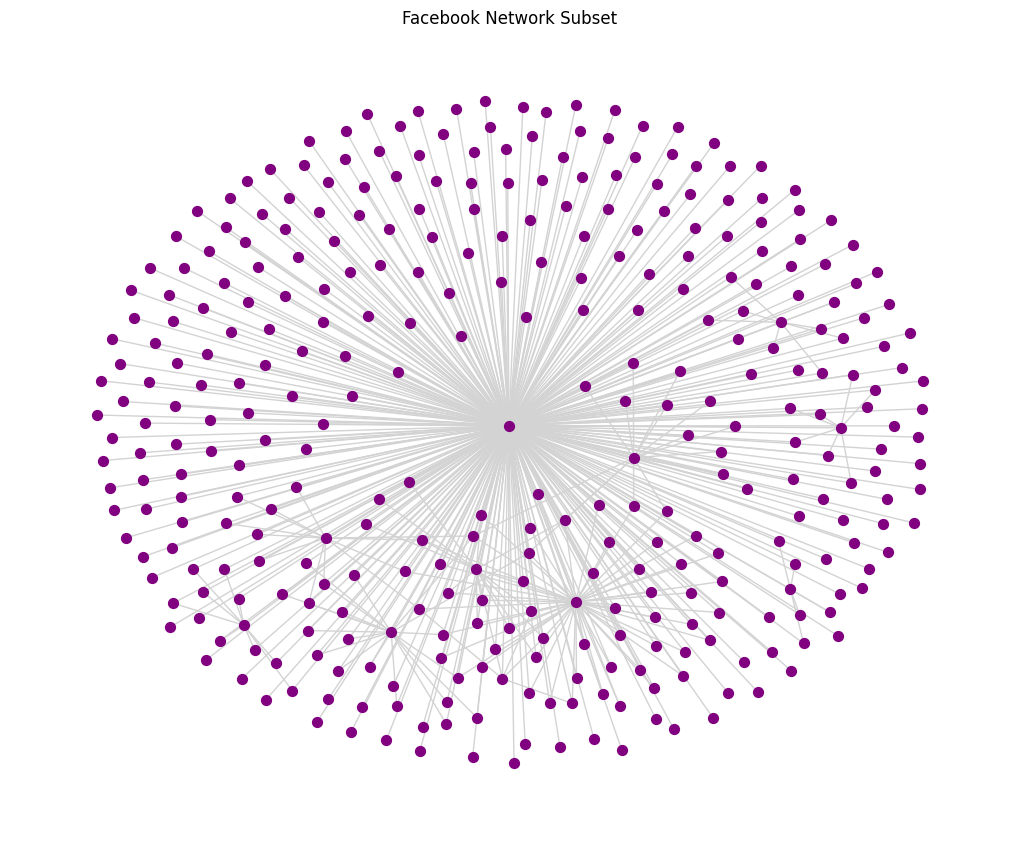

In [6]:
# This cell plots the network directly in Colab and generates a file for import into Gephi or Neo4j.

import matplotlib.pyplot as plt

# Visualize in Colab
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, seed=42)
nx.draw(G_sub, pos, node_size=50, node_color='purple', edge_color='lightgray')
plt.title("Facebook Network Subset")
plt.show()

# Export for Gephi/Neo4j
nx.write_graphml(G_sub, "stanford_subset.graphml")


# Visual Network Analysis

In [7]:
# The Central Hub: The single, heavily connected purple node in the middle represents the "ego" (a specific Facebook user).
# The radiating light gray lines show that this central user is directly connected to almost every other node in your 500-edge subset.
# Local Communities: The smaller, secondary hubs and cross-connections visible around the perimeter represent friendships between the central user's friends.
# This interconnectedness is exactly what your Average Clustering Coefficient metric is calculating.
# Graph Diameter Impact: Because the vast majority of nodes are directly connected to the central hub,
# the shortest path between any two random peripheral nodes is usually just 2 steps (Node A -> Central Hub -> Node B).
# Consequently, the calculated graph diameter for this subset will be very small.

In [8]:
# Generating the adjacency matrix for the connected component
adj_matrix = nx.to_numpy_array(G_sub)

# Displaying a 5x5 slice
print("Adjacency Matrix (First 5x5 slice):")
print(adj_matrix[:5, :5])

Adjacency Matrix (First 5x5 slice):
[[0. 1. 1. 1. 1.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]
